In [22]:
# using SparseArrays
# using LinearAlgebra
# using Plots

# # -----------------------
# # Material parameters
# # -----------------------
# #E  = 1.0
# #ν  = 0.3

# λ = 1.0 #E*ν/(1-ν^2)          # plane stress
# μ = 0.1 #E/(2*(1+ν))

# # Poisson ratio
# ν = λ/(2*(λ + μ))

# # -----------------------
# # Grid
# # -----------------------
# Nx = 5
# Ny = 5
# Lx = 1.0
# Ly = 1.0
# hx = Lx/(Nx-1)
# hy = Ly/(Ny-1)

# N = Nx*Ny
# Ndof = 2*N

# function idx(i,j,c)
#     node = (j-1)*Nx + i
#     return 2*(node-1) + c
# end

# rows = Int[]
# cols = Int[]
# vals = Float64[]
# b    = zeros(Ndof)

# function add(i,j,v)
#     push!(rows,i)
#     push!(cols,j)
#     push!(vals,v)
# end

# ε0 = 0.1

# # -----------------------
# # Assembly
# # -----------------------
# for j in 1:Ny
# for i in 1:Nx

#     # -------- Left boundary (fixed) --------
#     if i == 1
#         for comp in 1:2
#             row = idx(i,j,comp)
#             add(row,row,1.0)
#             b[row] = 0.0
#         end
#         continue
#     end

#     # -------- Right boundary (stretch) --------
#     if i == Nx
#         # a1 prescribed
#         row = idx(i,j,1)
#         add(row,row,1.0)
#         b[row] = ε0

#         # a2 free (natural already satisfied)
#         row = idx(i,j,2)
#         add(row,row,1.0)
#         b[row] = 0.0
#         continue
#     end

#     # -------- Bottom traction free --------
#     if j == 1
#         # σ_yy = 0
#         row = idx(i,j,2)

#         add(row, idx(i,j+1,2),  (λ+2μ)/hy)
#         add(row, idx(i,j,2),   -(λ+2μ)/hy)
#         add(row, idx(i+1,j,1),  λ/(2hx))
#         add(row, idx(i-1,j,1), -λ/(2hx))

#         # σ_xy = 0
#         row = idx(i,j,1)
#         add(row, idx(i,j+1,1),  μ/hy)
#         add(row, idx(i,j,1),   -μ/hy)
#         add(row, idx(i+1,j,2),  μ/(2hx))
#         add(row, idx(i-1,j,2), -μ/(2hx))
#         continue
#     end

#     # -------- Top traction free --------
#     if j == Ny
#         # σ_yy = 0
#         row = idx(i,j,2)

#         add(row, idx(i,j,2),    (λ+2μ)/hy)
#         add(row, idx(i,j-1,2), -(λ+2μ)/hy)
#         add(row, idx(i+1,j,1),  λ/(2hx))
#         add(row, idx(i-1,j,1), -λ/(2hx))

#         # σ_xy = 0
#         row = idx(i,j,1)
#         add(row, idx(i,j,1),    μ/hy)
#         add(row, idx(i,j-1,1), -μ/hy)
#         add(row, idx(i+1,j,2),  μ/(2hx))
#         add(row, idx(i-1,j,2), -μ/(2hx))
#         continue
#     end

#     # -------- Interior Navier equation --------
#     for comp in 1:2
#         row = idx(i,j,comp)

#         if comp == 1
#             add(row, idx(i,j,1), -2*(λ+2μ)/hx^2 - 2*μ/hy^2)
#             add(row, idx(i+1,j,1),(λ+2μ)/hx^2)
#             add(row, idx(i-1,j,1),(λ+2μ)/hx^2)
#             add(row, idx(i,j+1,1),μ/hy^2)
#             add(row, idx(i,j-1,1),μ/hy^2)

#             coeff = (λ+μ)/(4hx*hy)
#             add(row, idx(i+1,j+1,2),  coeff)
#             add(row, idx(i+1,j-1,2), -coeff)
#             add(row, idx(i-1,j+1,2), -coeff)
#             add(row, idx(i-1,j-1,2),  coeff)
#         else
#             add(row, idx(i,j,2), -2*(λ+2μ)/hy^2 - 2*μ/hx^2)
#             add(row, idx(i,j+1,2),(λ+2μ)/hy^2)
#             add(row, idx(i,j-1,2),(λ+2μ)/hy^2)
#             add(row, idx(i+1,j,2),μ/hx^2)
#             add(row, idx(i-1,j,2),μ/hx^2)

#             coeff = (λ+μ)/(4hx*hy)
#             add(row, idx(i+1,j+1,1),  coeff)
#             add(row, idx(i+1,j-1,1), -coeff)
#             add(row, idx(i-1,j+1,1), -coeff)
#             add(row, idx(i-1,j-1,1),  coeff)
#         end
#     end

# end
# end

# M = sparse(rows,cols,vals,Ndof,Ndof)

# u = M \ b

# a1 = reshape(u[1:2:end],Nx,Ny)
# a2 = reshape(u[2:2:end],Nx,Ny)

In [23]:
using SparseArrays
using LinearAlgebra
using Plots

# -----------------------
# Material parameters
# -----------------------
λ = 1.0
μ = 0.1

ν = λ/(2*(λ + μ))
println("Poisson ratio = ", ν)

# -----------------------
# Grid
# -----------------------
Nx = 5
Ny = 5
Lx = 1.0
Ly = 1.0
hx = Lx/(Nx-1)
hy = Ly/(Ny-1)

N = Nx*Ny
Ndof = 2*N

# -------- Blocked ordering ----------
# First N entries → a1
# Next  N entries → a2

function idx(i,j,c)
    node = (j-1)*Nx + i
    if c == 1
        return node
    else
        return node + N
    end
end

rows = Int[]
cols = Int[]
vals = Float64[]
b    = zeros(Ndof)

function add(i,j,v)
    push!(rows,i)
    push!(cols,j)
    push!(vals,v)
end

ε0 = 0.1

# -----------------------
# Assembly
# -----------------------
for j in 1:Ny
for i in 1:Nx

    # -------- Left boundary (fixed) --------
    if i == 1
        for comp in 1:2
            row = idx(i,j,comp)
            add(row,row,1.0)
            b[row] = 0.0
        end
        continue
    end

    # -------- Right boundary (stretch) --------
    if i == Nx
        # prescribe a1
        row = idx(i,j,1)
        add(row,row,1.0)
        b[row] = ε0

        # a2 
        row = idx(i,j,2)
        add(row,row,1.0)
        b[row] = 0.0        
        continue
    end

    # -------- Bottom traction free --------
    if j == 1
        # σ_yy = 0
        row = idx(i,j,2)
        add(row, idx(i,j+1,2),  (λ+2μ)/hy)
        add(row, idx(i,j,2),   -(λ+2μ)/hy)
        add(row, idx(i+1,j,1),  λ/(2hx))
        add(row, idx(i-1,j,1), -λ/(2hx))

        # σ_xy = 0
        row = idx(i,j,1)
        add(row, idx(i,j+1,1),  μ/hy)
        add(row, idx(i,j,1),   -μ/hy)
        add(row, idx(i+1,j,2),  μ/(2hx))
        add(row, idx(i-1,j,2), -μ/(2hx))
        continue
    end

    # -------- Top traction free --------
    if j == Ny
        # σ_yy = 0
        row = idx(i,j,2)
        add(row, idx(i,j,2),    (λ+2μ)/hy)
        add(row, idx(i,j-1,2), -(λ+2μ)/hy)
        add(row, idx(i+1,j,1),  λ/(2hx))
        add(row, idx(i-1,j,1), -λ/(2hx))

        # σ_xy = 0
        row = idx(i,j,1)
        add(row, idx(i,j,1),    μ/hy)
        add(row, idx(i,j-1,1), -μ/hy)
        add(row, idx(i+1,j,2),  μ/(2hx))
        add(row, idx(i-1,j,2), -μ/(2hx))
        continue
    end

    # -------- Interior Navier equation --------
    for comp in 1:2
        row = idx(i,j,comp)

        if comp == 1
            add(row, idx(i,j,1), -2*(λ+2μ)/hx^2 - 2*μ/hy^2)
            add(row, idx(i+1,j,1),(λ+2μ)/hx^2)
            add(row, idx(i-1,j,1),(λ+2μ)/hx^2)
            add(row, idx(i,j+1,1),μ/hy^2)
            add(row, idx(i,j-1,1),μ/hy^2)

            coeff = (λ+μ)/(4hx*hy)
            add(row, idx(i+1,j+1,2),  coeff)
            add(row, idx(i+1,j-1,2), -coeff)
            add(row, idx(i-1,j+1,2), -coeff)
            add(row, idx(i-1,j-1,2),  coeff)

        else
            add(row, idx(i,j,2), -2*(λ+2μ)/hy^2 - 2*μ/hx^2)
            add(row, idx(i,j+1,2),(λ+2μ)/hy^2)
            add(row, idx(i,j-1,2),(λ+2μ)/hy^2)
            add(row, idx(i+1,j,2),μ/hx^2)
            add(row, idx(i-1,j,2),μ/hx^2)

            coeff = (λ+μ)/(4hx*hy)
            add(row, idx(i+1,j+1,1),  coeff)
            add(row, idx(i+1,j-1,1), -coeff)
            add(row, idx(i-1,j+1,1), -coeff)
            add(row, idx(i-1,j-1,1),  coeff)
        end
    end

end
end

# -----------------------
# Solve
# -----------------------
M = sparse(rows,cols,vals,Ndof,Ndof)
u = M \ b

# Extract solution (blocked format)
a1 = reshape(u[1:N], Nx, Ny)
a2 = reshape(u[N+1:end], Nx, Ny)

Poisson ratio = 0.45454545454545453


5×5 Matrix{Float64}:
 0.0        0.0         0.0           0.0         0.0
 0.0400044  0.0191711  -4.33201e-18  -0.0191711  -0.0400044
 0.0293409  0.0183955  -5.60934e-18  -0.0183955  -0.0293409
 0.0400044  0.0191711  -8.661e-19    -0.0191711  -0.0400044
 0.0        0.0         0.0           0.0         0.0

In [122]:
i = 50
M[i,:]

50-element SparseVector{Float64, Int64} with 1 stored entry:
  [50]  =  1.0

In [123]:
b[i]

0.0

Measured Poisson ratio ≈ 0.8000887757276572
Theoretical ν = 0.45454545454545453


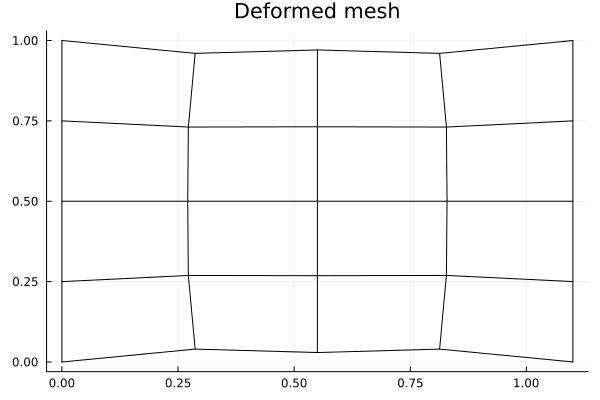

In [26]:
# -----------------------
# Check Poisson squeeze
# -----------------------
mid = div(Ny,2)
εx = (a1[end,mid] - a1[1,mid]) / Lx
εy = (a2[mid,Ny] - a2[mid,1]) / Ly

println("Measured Poisson ratio ≈ ", -εy/εx)
println("Theoretical ν = ", ν)

# -----------------------
# Plot deformation
# -----------------------
x = range(0,Lx,length=Nx)
y = range(0,Ly,length=Ny)

X = [xi for xi in x, yi in y]
Y = [yi for xi in x, yi in y]

scale = 1  # exaggerate deformation for visualization

p = plot()
for j in 1:Ny
    plot!(p, X[:,j] .+ scale*a1[:,j],
              Y[:,j] .+ scale*a2[:,j],
              color=:black,
              legend=false)
end
for i in 1:Nx
    plot!(p, X[i,:] .+ scale*a1[i,:],
              Y[i,:] .+ scale*a2[i,:],
              color=:black,
              legend=false)
end

title!(p,"Deformed mesh")
display(p)